# Lab Assignment 1

## Question 1

### 1. Load Data & Encode

In [2]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

df = pd.read_csv('voice.csv')

le = LabelEncoder()
df['label'] = le.fit_transform(df['label']) # 1 for male, 0 for female

### 2. Separate Feature

In [3]:
X_raw = df.drop('label', axis=1)
y = df['label']

### 3. Standardize the feature

In [4]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_raw)
X_scaled = pd.DataFrame(X_scaled, columns=X_raw.columns)

### 4. Data splitting (80% train, 20% test)

In [5]:
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

### 5. Construct Model

In [6]:
knn_base = KNeighborsClassifier(n_neighbors=5)
knn_base.fit(X_train, y_train)
print(f"Base Model Accuracy (All Features): {accuracy_score(y_test, knn_base.predict(X_test)):.4f}")

Base Model Accuracy (All Features): 0.9811


## Question 2: Experiment

### Corellation Matrix

label       1.000000
meanfun     0.833921
IQR         0.618916
Q25         0.511455
sp.ent      0.490552
sd          0.479539
sfm         0.357499
meanfreq    0.337415
centroid    0.337415
median      0.283919
maxdom      0.195657
mindom      0.194974
dfrange     0.192213
meandom     0.191067
mode        0.171775
maxfun      0.166461
minfun      0.136692
kurt        0.087195
Q75         0.066906
skew        0.036627
modindx     0.030801
Name: label, dtype: float64


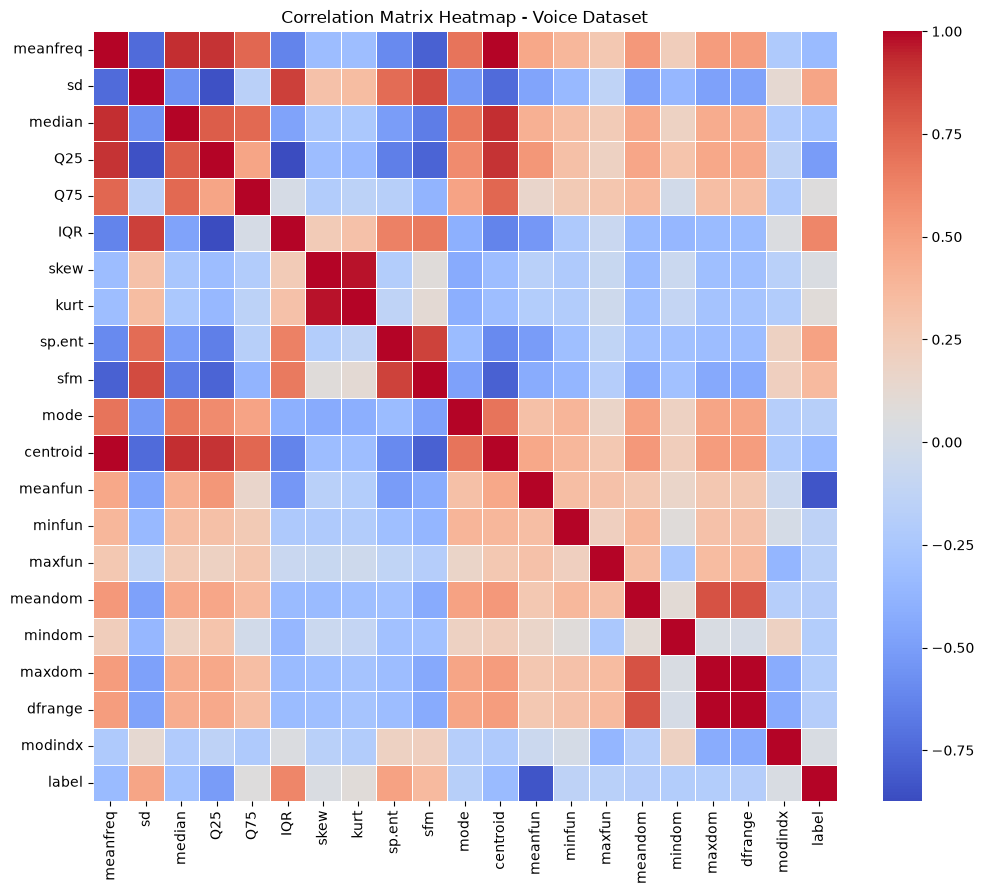

In [12]:
le = LabelEncoder()
df['label'] = le.fit_transform(df['label']) # e.g., female: 0, male: 1

corr_matrix = df.corr()

print(corr_matrix['label'].abs().sort_values(ascending=False))

plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix, cmap='coolwarm', annot=False, fmt='.2f', linewidths=0.5)
plt.title('Correlation Matrix Heatmap - Voice Dataset')
plt.show()

In [13]:
import seaborn as sns
import matplotlib.pyplot as plt

correlations = df.corr()['label'].drop('label').abs().sort_values(ascending=False)
print("Top 5 Highly Correlated Features:\n", correlations.head())

optimal_features = ['meanfun', 'IQR', 'Q25']
X_opt_train = X_train[optimal_features]
X_opt_test = X_test[optimal_features]

Top 5 Highly Correlated Features:
 meanfun    0.833921
IQR        0.618916
Q25        0.511455
sp.ent     0.490552
sd         0.479539
Name: label, dtype: float64


Based on the correlation experiment for voice.csv, the three features are the most optimal to employ are meanfun, IQR and Q25

## Question 3: Best k Value

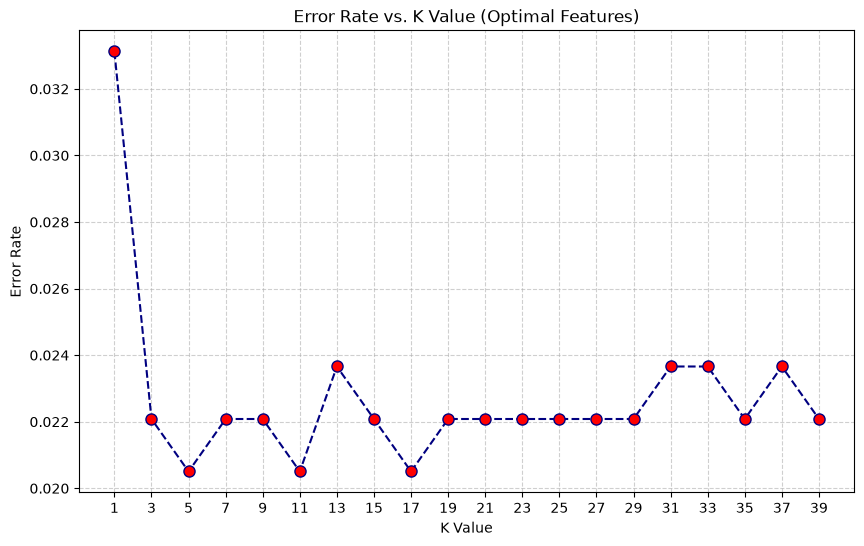

The best k value based on the lowest error rate is: k=5


In [17]:
import numpy as np

error_rates = []
k_values = range(1, 40, 2)

# Iterate through k 
for k in k_values:
    knn_opt = KNeighborsClassifier(n_neighbors=k)
    knn_opt.fit(X_opt_train, y_train)
    y_pred_opt = knn_opt.predict(X_opt_test)
    # Calculate error rate (1 - accuracy)
    # inside the loop
    error = 1 - accuracy_score(y_test, y_pred_opt)
    error_rates.append(error)

plt.figure(figsize=(10, 6))
plt.plot(k_values, error_rates, color='navy', linestyle='dashed', marker='o',
         markerfacecolor='red', markersize=8)
plt.title('Error Rate vs. K Value (Optimal Features)')
plt.xlabel('K Value')
plt.ylabel('Error Rate')
plt.xticks(k_values)
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

# Print the mathematically optimal K
optimal_k = k_values[np.argmin(error_rates)]
print(f"The best k value based on the lowest error rate is: k={optimal_k}")